Author: Nicolas Legrand <nicolas.legrand@cas.au.dk>

In [1]:
import numpy as np
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pingouin as pg
from pathlib import Path

plt.rcParams["figure.constrained_layout.use"] = True

## Visualisation

In [2]:
cardiac_hgf_df = pd.read_csv(
    Path.cwd().parent.parent / "results" / "cardiac_hgf_summary.csv"
)
cardiac_hgf_df = cardiac_hgf_df[cardiac_hgf_df.session == 2]

In [3]:
cardiac_hgf_df

,participant_id,session,interoceptive_precision,exteroceptive_precision,interoceptive_tonic_volatility,exteroceptive_tonic_volatility,exteroceptive_mean,interoceptive_mean,interoceptive_sensitivity,exteroceptive_sensitivity,logit_interoceptive_sensitivity,logit_exteroceptive_sensitivity
1,sub-0019,2,0.760837,0.027574,-24.679379,29.462154,105.019992,136.138332,0.432088,1.0,-0.273336,25.871288
4,sub-0022,2,0.007320,0.221279,-26.409460,27.024638,103.334650,48.877177,0.007267,1.0,-4.917078,25.516305
6,sub-0023,2,0.068022,0.043423,-27.071767,28.708783,105.346721,54.568341,0.063689,1.0,-2.687930,25.572024
8,sub-0024,2,0.230005,0.035593,-24.897506,28.587856,103.814490,73.019234,0.186995,1.0,-1.469656,25.252241
10,sub-0025,2,0.020349,0.017246,-27.351261,29.495329,106.288009,42.642156,0.019943,1.0,-3.894747,25.435155
...,...,...,...,...,...,...,...,...,...,...,...,...
731,sub-0631,2,0.359205,0.019457,-26.726312,29.052101,105.789219,43.795793,0.264276,1.0,-1.023863,25.112542
732,sub-0632,2,1.045357,0.001165,0.911396,26.438237,105.029775,90.774207,0.784761,1.0,1.293627,19.682933
733,sub-0633,2,1.162345,0.010673,-21.865659,29.054985,106.180035,51.767263,0.537539,1.0,0.150440,24.514980
734,sub-0638,2,0.937983,0.002327,7.773126,30.441489,105.986336,80.978795,0.999552,1.0,7.709523,24.378257


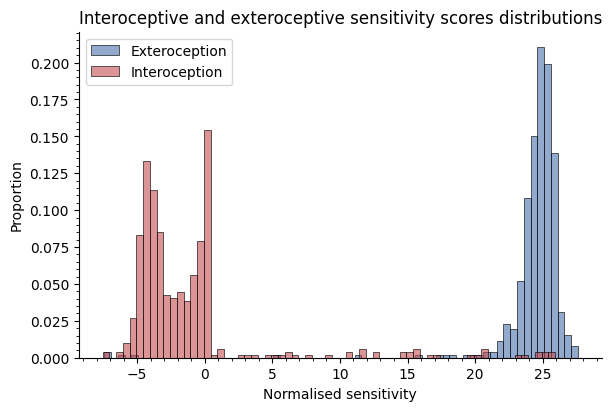

In [7]:
_, ax = plt.subplots(figsize=(6, 4))

sns.histplot(
    cardiac_hgf_df.logit_exteroceptive_sensitivity.to_numpy(),
    color="#4c72b0",
    alpha=0.6,
    stat="proportion",
    binwidth=.5,
    label="Exteroception",
    ax=ax,
)

sns.histplot(
    cardiac_hgf_df.logit_interoceptive_sensitivity.to_numpy(),
    color="#c44e52",
    alpha=0.6,
    stat="proportion",
    binwidth=.5,
    label="Interoception",
    ax=ax,
)
ax.set(
    title="Interoceptive and exteroceptive sensitivity scores distributions",
    xlabel="Normalised sensitivity",
)
ax.legend()
ax.minorticks_on()
sns.despine()

plt.savefig(Path().cwd().parent.parent / "figures" / "figure_4_intero_extero.svg")

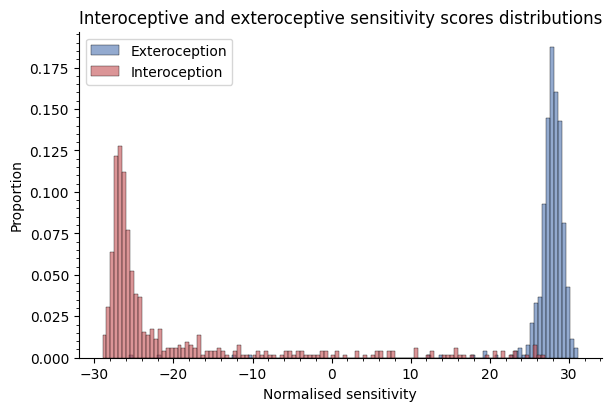

In [8]:
_, ax = plt.subplots(figsize=(6, 4))

sns.histplot(
    cardiac_hgf_df.exteroceptive_tonic_volatility.to_numpy(),
    color="#4c72b0",
    alpha=0.6,
    stat="proportion",
    binwidth=.5,
    label="Exteroception",
    ax=ax,
)

sns.histplot(
    cardiac_hgf_df.interoceptive_tonic_volatility.to_numpy(),
    color="#c44e52",
    alpha=0.6,
    stat="proportion",
    binwidth=.5,
    label="Interoception",
    ax=ax,
)
ax.set(
    title="Interoceptive and exteroceptive sensitivity scores distributions",
    xlabel="Normalised sensitivity",
)
ax.legend()
ax.minorticks_on()
sns.despine()

plt.savefig(Path().cwd().parent.parent / "figures" / "figure_4_intero_extero.svg")

In [9]:
cardiac_hgf_df = pd.read_csv(
    Path.cwd().parent.parent / "results" / "cardiac_hgf_summary.csv"
)
merged = pd.merge(
    cardiac_hgf_df[cardiac_hgf_df.session == 1],
    cardiac_hgf_df[cardiac_hgf_df.session == 2],
    on="participant_id",
    suffixes=("_del1", "_del2"),
)

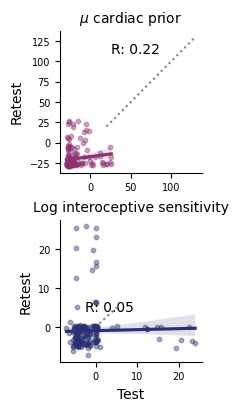

In [11]:
fig, axs = plt.subplots(figsize=(2, 4), nrows=2)

sns.regplot(
    x=merged["interoceptive_tonic_volatility_del1"],
    y=merged["interoceptive_tonic_volatility_del2"],
    scatter_kws={"s": 10, "alpha": .4},
    color="#8b3170",
    ax=axs[0]
)
axs[0].annotate(
    f"R: {round(pg.corr(
    x=merged["interoceptive_tonic_volatility_del1"].to_numpy(),
    y=merged["interoceptive_tonic_volatility_del2"].to_numpy(),
    method="spearman",
).r.iloc[0], 2)}",
    (25, 110)
)

sns.regplot(
    x=merged["logit_interoceptive_sensitivity_del1"],
    y=merged["logit_interoceptive_sensitivity_del2"],
    color="#2c3071",
    scatter_kws={"s": 10, "alpha": .4},
    ax=axs[1]
)
axs[1].annotate(
    f"R: {round(pg.corr(
    x=merged["logit_exteroceptive_sensitivity_del1"].to_numpy(),
    y=merged["logit_exteroceptive_sensitivity_del2"].to_numpy(),
    method="spearman",
).r.iloc[0], 2)}",
    (-2.5, 4)
)

axs[0].plot((20, 130), (20, 130), linestyle=":", color="gray", zorder=0)
axs[0].tick_params(axis='both', labelsize=7)
axs[0].set_title(r"$\mu$ cardiac prior", fontsize=10)
axs[1].plot((-3, 5), (-3,5), linestyle=":", color="gray", zorder=0)
axs[1].tick_params(axis='both', labelsize=7)
axs[1].set_title("Log interoceptive sensitivity", fontsize=10)

axs[0].set(xlabel=None, ylabel="Retest")
axs[1].set(xlabel="Test", ylabel="Retest")

sns.despine()

plt.savefig(Path().cwd().parent.parent / "figures" / "figure_3_reliability.svg")